In [ ]:
import time
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import emoji, re, string

import nltk
from nltk.corpus import stopwords
import spacy


from datasets import Dataset


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
import evaluate


d:\Arquivos_Acer\Documents\UFC\PrejudicePT-br-main\ambiente_prejudice\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv('../../Datasets/Correto_whatsapp_rotulado_revisado.csv')
df.head()

,text_content_anonymous,preconceito
0,Show :clapping_hands_light_skin_tone::clapping...,0
1,Mais uma vez o PT= Partido das Trevas apela ao...,1
2,Se não puder avise só para não quebrar a vigíl...,0
3,E a esquerda tenta impedir o trabalho,0
4,Deus perdoa porque eles Não sabem que fazem e ...,0


In [3]:
df.shape

(3000, 2)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 2 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   text_content_anonymous  2999 non-null   object
 1   preconceito             3000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 47.0+ KB


In [3]:
mensagens_coluna = 'text_content_anonymous'  
df[mensagens_coluna] = df[mensagens_coluna].astype(str) # garantindo que todos os valores são strings

# Tokenizar mensagens (simples divisão por espaços)
df['num_tokens'] = df[mensagens_coluna].apply(lambda x: len(x.split()))

## Processamento do texto

In [4]:
unicode_emoji = {}
for key, value in emoji.EMOJI_DATA.items():
    try:
        unicode_emoji[key] = value['pt']
    except:
        pass

#emojis and punctuation
emojis_list = list(unicode_emoji)
punct = list(string.punctuation)
emojis_punct = emojis_list + punct

def processEmojisPunctuation(text, remove_punct = True):
    '''
    Put spaces between emojis. Removes punctuation.
    '''
    #get all unique chars
    chars = set(text)
    #for each unique char in text, do:
    for c in chars:
        #remove punctuation
        if remove_punct:
            if c in emojis_list:
                text = text.replace(c, ' ' + c + ' ')
            if c in punct:
                text = text.replace(c, ' ')

        #put spaces between punctuation
        else:
            if c in emojis_punct:
                text = text.replace(c, ' ' + c + ' ')          

    text = text.replace('  ', ' ')
    return text

#stop words removal
stop_words = list(stopwords.words('portuguese'))
new_stopwords = ['aí','pra','vão','vou','onde','lá','aqui',
                 'tá','pode','pois','so','deu','agora','todo',
                 'nao','ja','vc', 'bom', 'ai','kkk','kkkk','ta', 'voce', 'alguem', 'ne', 'pq',
                 'cara','to','mim','la','vcs','tbm', 'tudo']
stop_words = stop_words + new_stopwords
final_stop_words = []
for sw in stop_words:
    sw = ' '+ sw + ' '
    final_stop_words.append(sw)

def removeStopwords(text):
    for sw in final_stop_words:
        text = text.replace(sw,' ')
    text = text.replace('  ',' ')
    return text

#lemmatization
nlp = spacy.load('pt_core_news_sm')
def lemmatization(text):
    doc = nlp(text)
    for token in doc:
        if token.text != token.lemma_:
            text = text.replace(token.text, token.lemma_)
    return text


def domainUrl(text):
    '''
    Substitutes an URL in a text for the domain of this URL
    Input: an string
    Output: the string with the modified URL
    '''    
    if 'http' in text:
        re_url = '[^\s]*https*://[^\s]*'
        matches = re.findall(re_url, text, flags=re.IGNORECASE)
        for m in matches:
            domain = m.split('//')
            domain = domain[1].split('/')[0]
            text = re.sub(re_url, domain, text, 1)
        return text
    else:
        return text 

def preprocess(text):
    text = text.lower().strip()
    text = domainUrl(text)
    text = processEmojisPunctuation(text)
    text = removeStopwords(text)
    text = lemmatization(text)
    return text


In [ ]:
# === Renomeando colunas ===
df = df.rename(columns={
    "text_content_anonymous": "text",
    "preconceito": "label"
})
df["label"] = df["label"].astype(int)


In [14]:
df.head()

,text,label
0,Show :clapping_hands_light_skin_tone::clapping...,0
1,Mais uma vez o PT= Partido das Trevas apela ao...,1
2,Se não puder avise só para não quebrar a vigíl...,0
3,E a esquerda tenta impedir o trabalho,0
4,Deus perdoa porque eles Não sabem que fazem e ...,0


In [17]:
# Função de pré-processamento
def preprocess_data(df, experiment):
    if 'processed' in experiment:
        print("Pré-processamento ativado.")
        pro_texts = [preprocess(t) for t in df['text']]
    else:
        print("Sem pré-processamento.")
        pro_texts = [processEmojisPunctuation(t.lower(), remove_punct=False) for t in df['text']]
    return pro_texts


## Modelos Pré treinados - Sem pré processamento

In [18]:
# === Pré-processamento dinâmico ===
df["text"] = preprocess_data(df, experiment="raw")  
df.head()

Sem pré-processamento.


,text,label
0,show : clapping _ hands _ light _ skin _ tone ...,0
1,mais uma vez o pt = partido das trevas apela a...,1
2,se não puder avise só para não quebrar a vigíl...,0
3,e a esquerda tenta impedir o trabalho,0
4,deus perdoa porque eles não sabem que fazem e ...,0


### melll-uff/bertweetbr

=== Fold 1 ===


Map: 100%|██████████| 600/600 [00:00<00:00, 1611.25 examples/s]
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at melll-uff/bertweetbr and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\Melissa Felipe\AppData\Local\Temp\ipykernel_57328\2364779005.py:64: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss


=== Fold 2 ===


Map: 100%|██████████| 600/600 [00:00<00:00, 1762.84 examples/s]
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at melll-uff/bertweetbr and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\Melissa Felipe\AppData\Local\Temp\ipykernel_57328\2364779005.py:64: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


...

Map: 100%|██████████| 600/600 [00:00<00:00, 1645.30 examples/s]
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at melll-uff/bertweetbr and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\Melissa Felipe\AppData\Local\Temp\ipykernel_57328\2364779005.py:64: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss


=== Fold 5 ===


Map: 100%|██████████| 600/600 [00:00<00:00, 1776.92 examples/s]
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at melll-uff/bertweetbr and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\Melissa Felipe\AppData\Local\Temp\ipykernel_57328\2364779005.py:64: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss


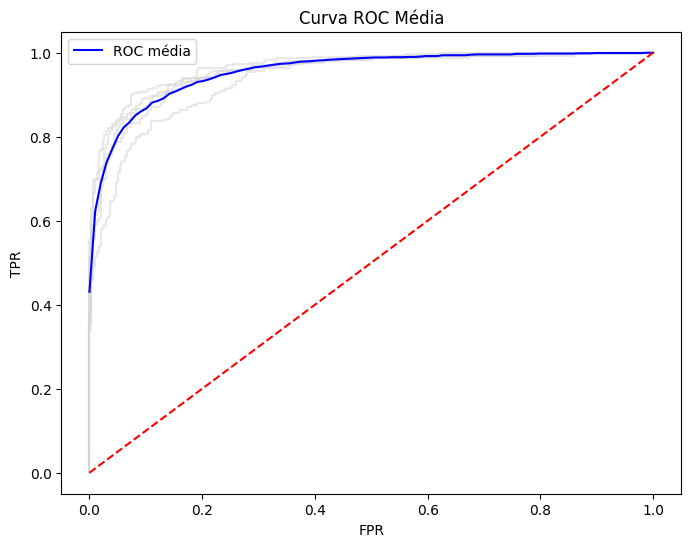

In [ ]:

# === Configurações ===
model_name = "melll-uff/bertweetbr"
tokenizer = AutoTokenizer.from_pretrained(model_name)


num_labels = df["label"].nunique()
id2label = {i: f"Classe {i}" for i in range(num_labels)}
label2id = {v: k for k, v in id2label.items()}


# Função de tokenização
def tokenize_fn(examples):
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=128)

# === Cross Validation ===
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

metrics_results = []
roc_curves = []
start_total = time.time()

for fold, (train_idx, test_idx) in enumerate(skf.split(df["text"], df["label"]), start=1):
    print(f"=== Fold {fold} ===")

    train_df = df.iloc[train_idx]
    test_df = df.iloc[test_idx]

    # Converte para Dataset do HF
    train_dataset = Dataset.from_pandas(train_df).map(tokenize_fn, batched=True)
    test_dataset = Dataset.from_pandas(test_df).map(tokenize_fn, batched=True)

    # Carrega modelo novo a cada fold
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, 
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id,
        use_safetensors=True,
        ignore_mismatched_sizes=True  # o modelo foi treinado com 12 classes, mas estou ignorando o 
                                        # erro de incompatibilidade de forma na camada final e recriar a Linear layer com num_labels=3. 
    )

    # Configuração de treinamento
    training_args = TrainingArguments(
        #output_dir=f"./results_fold_{fold}",
        #evaluation_strategy="no",
        save_strategy="no",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=3,
        #logging_dir=f"./logs_fold_{fold}",
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        tokenizer=tokenizer
    )

    fold_start_fold = time.time()

    trainer.train()
    # Predições
    preds = trainer.predict(test_dataset)

    fold_end_time = time.time()
    fold_execution_time = fold_end_time - fold_start_fold

    # Predições e métricas
    y_true = np.array(test_df["label"])
    y_pred = np.argmax(preds.predictions, axis=1)
    y_prob = preds.predictions[:, 1]

    # Métricas
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)

    metrics_results.append({
        "fold": fold,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": roc_auc,
        "time_sec": fold_execution_time
    })

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_curves.append((fpr, tpr))

# Tempo total do experimento 
total_time = time.time() - start_total

# === Estatísticas ===
metrics_df = pd.DataFrame(metrics_results)
summary = {
    "accuracy_avg": metrics_df["accuracy"].mean(),
    "accuracy_std": metrics_df["accuracy"].std(),
    "precision_avg": metrics_df["precision"].mean(),
    "precision_std": metrics_df["precision"].std(),
    "recall_avg": metrics_df["recall"].mean(),
    "recall_std": metrics_df["recall"].std(),
    "f1_avg": metrics_df["f1"].mean(),
    "f1_std": metrics_df["f1"].std(),
    "roc_auc_avg": metrics_df["roc_auc"].mean(),
    "roc_auc_std": metrics_df["roc_auc"].std(),
    "total_time_sec": total_time
}

# Salvar CSV
metrics_df.to_csv("./resultados/resultados_folds_melll_uff_Sempre_processamento.csv", index=False)
pd.DataFrame([summary]).to_csv("./resultados/resultados_resumo_melll_uff_Sempre_processamento.csv", index=False)

# === Plot Curva ROC média ===
plt.figure(figsize=(8, 6))
for fpr, tpr in roc_curves:
    plt.plot(fpr, tpr, color="lightgray", alpha=0.5)

mean_fpr = np.linspace(0, 1, 100)
mean_tpr = np.zeros_like(mean_fpr)
for fpr, tpr in roc_curves:
    mean_tpr += np.interp(mean_fpr, fpr, tpr)
mean_tpr /= len(roc_curves)

plt.plot(mean_fpr, mean_tpr, color="blue", label="ROC média")
plt.plot([0, 1], [0, 1], linestyle="--", color="red")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Curva ROC Média")
plt.legend()
plt.savefig("./resultados/roc_media_melll_uff_Sempre_processamento.png", dpi=300)
plt.show()


### FpOliveira/tupi-bert-base-portuguese-cased

d:\Arquivos_Acer\Documents\UFC\PrejudicePT-br-main\ambiente_prejudice\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Melissa Felipe\.cache\huggingface\hub\models--FpOliveira--tupi-bert-base-portuguese-cased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


=== Fold 1 ===


Map: 100%|██████████| 600/600 [00:00<00:00, 14915.47 examples/s]
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
C:\Users\Melissa Felipe\AppData\Local\Temp\ipykernel_10016\2379516802.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss


=== Fold 2 ===


...

Map: 100%|██████████| 600/600 [00:00<00:00, 13613.16 examples/s]
C:\Users\Melissa Felipe\AppData\Local\Temp\ipykernel_10016\2379516802.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss


=== Fold 5 ===


Map: 100%|██████████| 600/600 [00:00<00:00, 8613.33 examples/s]
C:\Users\Melissa Felipe\AppData\Local\Temp\ipykernel_10016\2379516802.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss


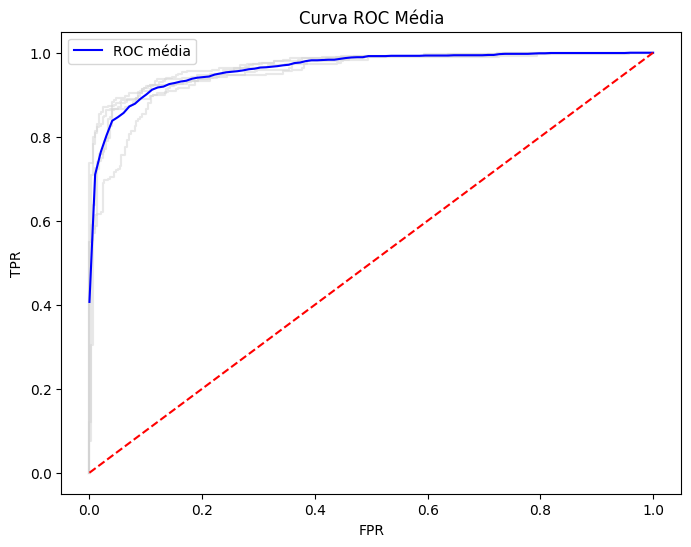

In [19]:

# === Configurações ===
model_name = "FpOliveira/tupi-bert-base-portuguese-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)


num_labels = df["label"].nunique()
id2label = {i: f"Classe {i}" for i in range(num_labels)}
label2id = {v: k for k, v in id2label.items()}


# Função de tokenização
def tokenize_fn(examples):
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=128)

# === Cross Validation ===
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

metrics_results = []
roc_curves = []
start_total = time.time()

for fold, (train_idx, test_idx) in enumerate(skf.split(df["text"], df["label"]), start=1):
    print(f"=== Fold {fold} ===")

    train_df = df.iloc[train_idx]
    test_df = df.iloc[test_idx]

    # Converte para Dataset do HF
    from datasets import Dataset
    train_dataset = Dataset.from_pandas(train_df).map(tokenize_fn, batched=True)
    test_dataset = Dataset.from_pandas(test_df).map(tokenize_fn, batched=True)

    # Carrega modelo novo a cada fold
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, 
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id,
        use_safetensors=True,
        ignore_mismatched_sizes=True  # o modelo foi treinado com 12 classes, mas estou ignorando o 
                                        # erro de incompatibilidade de forma na camada final e recriar a Linear layer com num_labels=3. 
    )

    # Configuração de treinamento
    training_args = TrainingArguments(
        #output_dir=f"./results_fold_{fold}",
        #evaluation_strategy="no",
        save_strategy="no",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=3,
        #logging_dir=f"./logs_fold_{fold}",
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        tokenizer=tokenizer
    )

    start_fold = time.time()
    trainer.train()
    elapsed_fold = time.time() - start_fold

    # Predições
    preds = trainer.predict(test_dataset)
    y_true = np.array(test_df["label"])
    y_pred = np.argmax(preds.predictions, axis=1)
    y_prob = preds.predictions[:, 1]

    # Métricas
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)

    metrics_results.append({
        "fold": fold,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": roc_auc,
        "time_sec": elapsed_fold
    })

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_curves.append((fpr, tpr))

total_time = time.time() - start_total

# === Estatísticas ===
metrics_df = pd.DataFrame(metrics_results)
summary = {
    "accuracy_avg": metrics_df["accuracy"].mean(),
    "accuracy_std": metrics_df["accuracy"].std(),
    "precision_avg": metrics_df["precision"].mean(),
    "precision_std": metrics_df["precision"].std(),
    "recall_avg": metrics_df["recall"].mean(),
    "recall_std": metrics_df["recall"].std(),
    "f1_avg": metrics_df["f1"].mean(),
    "f1_std": metrics_df["f1"].std(),
    "roc_auc_avg": metrics_df["roc_auc"].mean(),
    "roc_auc_std": metrics_df["roc_auc"].std(),
    "total_time_sec": total_time
}

# Salvar CSV
metrics_df.to_csv("./resultados/resultados_folds_FpOliveira_Sempre_processamento.csv", index=False)
pd.DataFrame([summary]).to_csv("./resultados/resultados_resumo_FpOliveira_Sempre_processamento.csv", index=False)

# === Plot Curva ROC média ===
plt.figure(figsize=(8, 6))
for fpr, tpr in roc_curves:
    plt.plot(fpr, tpr, color="lightgray", alpha=0.5)

mean_fpr = np.linspace(0, 1, 100)
mean_tpr = np.zeros_like(mean_fpr)
for fpr, tpr in roc_curves:
    mean_tpr += np.interp(mean_fpr, fpr, tpr)
mean_tpr /= len(roc_curves)

plt.plot(mean_fpr, mean_tpr, color="blue", label="ROC média")
plt.plot([0, 1], [0, 1], linestyle="--", color="red")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Curva ROC Média")
plt.legend()
plt.savefig("./resultados/roc_media_FpOliveira_Sempre_processamento.png", dpi=300)
plt.show()


### ruanchaves/bert-base-portuguese-cased-hatebr

=== Fold 1 ===


Map: 100%|██████████| 600/600 [00:00<00:00, 14544.11 examples/s]
C:\Users\Melissa Felipe\AppData\Local\Temp\ipykernel_10016\1264454331.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss


=== Fold 2 ===


Map: 100%|██████████| 600/600 [00:00<00:00, 14446.59 examples/s]
C:\Users\Melissa Felipe\AppData\Local\Temp\ipykernel_10016\1264454331.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


...

Map: 100%|██████████| 600/600 [00:00<00:00, 14534.96 examples/s]
C:\Users\Melissa Felipe\AppData\Local\Temp\ipykernel_10016\1264454331.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss


=== Fold 5 ===


Map: 100%|██████████| 600/600 [00:00<00:00, 15587.96 examples/s]
C:\Users\Melissa Felipe\AppData\Local\Temp\ipykernel_10016\1264454331.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss


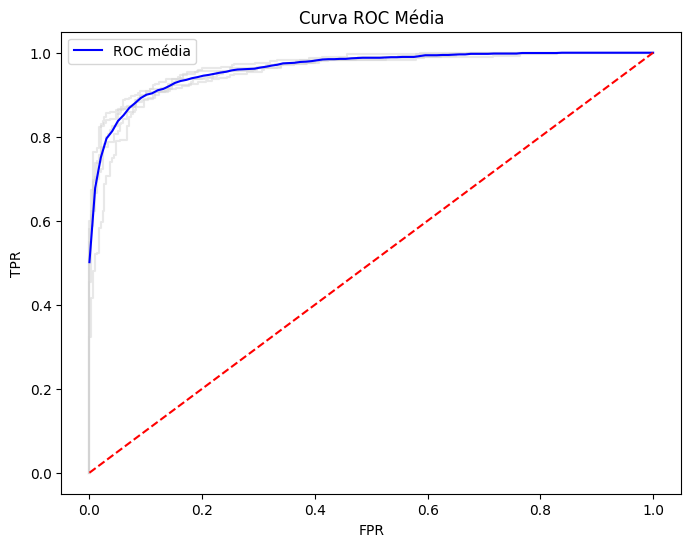

In [20]:

# === Configurações ===
model_name = "ruanchaves/bert-base-portuguese-cased-hatebr"
tokenizer = AutoTokenizer.from_pretrained(model_name)


num_labels = df["label"].nunique()
id2label = {i: f"Classe {i}" for i in range(num_labels)}
label2id = {v: k for k, v in id2label.items()}


# Função de tokenização
def tokenize_fn(examples):
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=128)

# === Cross Validation ===
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

metrics_results = []
roc_curves = []
start_total = time.time()

for fold, (train_idx, test_idx) in enumerate(skf.split(df["text"], df["label"]), start=1):
    print(f"=== Fold {fold} ===")

    train_df = df.iloc[train_idx]
    test_df = df.iloc[test_idx]

    # Converte para Dataset do HF
    from datasets import Dataset
    train_dataset = Dataset.from_pandas(train_df).map(tokenize_fn, batched=True)
    test_dataset = Dataset.from_pandas(test_df).map(tokenize_fn, batched=True)

    # Carrega modelo novo a cada fold
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, 
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id,
        use_safetensors=True,
        ignore_mismatched_sizes=True  # o modelo foi treinado com 12 classes, mas estou ignorando o 
                                        # erro de incompatibilidade de forma na camada final e recriar a Linear layer com num_labels=3. 
    )

    # Configuração de treinamento
    training_args = TrainingArguments(
        #output_dir=f"./results_fold_{fold}",
        #evaluation_strategy="no",
        save_strategy="no",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=3,
        #logging_dir=f"./logs_fold_{fold}",
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        tokenizer=tokenizer
    )

    start_fold = time.time()
    trainer.train()
    elapsed_fold = time.time() - start_fold

    # Predições
    preds = trainer.predict(test_dataset)
    y_true = np.array(test_df["label"])
    y_pred = np.argmax(preds.predictions, axis=1)
    y_prob = preds.predictions[:, 1]

    # Métricas
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)

    metrics_results.append({
        "fold": fold,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": roc_auc,
        "time_sec": elapsed_fold
    })

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_curves.append((fpr, tpr))

total_time = time.time() - start_total

# === Estatísticas ===
metrics_df = pd.DataFrame(metrics_results)
summary = {
    "accuracy_avg": metrics_df["accuracy"].mean(),
    "accuracy_std": metrics_df["accuracy"].std(),
    "precision_avg": metrics_df["precision"].mean(),
    "precision_std": metrics_df["precision"].std(),
    "recall_avg": metrics_df["recall"].mean(),
    "recall_std": metrics_df["recall"].std(),
    "f1_avg": metrics_df["f1"].mean(),
    "f1_std": metrics_df["f1"].std(),
    "roc_auc_avg": metrics_df["roc_auc"].mean(),
    "roc_auc_std": metrics_df["roc_auc"].std(),
    "total_time_sec": total_time
}

# Salvar CSV
metrics_df.to_csv("./resultados/resultados_folds_ruanchaves_Sempre_processamento.csv", index=False)
pd.DataFrame([summary]).to_csv("./resultados/resultados_resumo_ruanchaves_Sempre_processamento.csv", index=False)

# === Plot Curva ROC média ===
plt.figure(figsize=(8, 6))
for fpr, tpr in roc_curves:
    plt.plot(fpr, tpr, color="lightgray", alpha=0.5)

mean_fpr = np.linspace(0, 1, 100)
mean_tpr = np.zeros_like(mean_fpr)
for fpr, tpr in roc_curves:
    mean_tpr += np.interp(mean_fpr, fpr, tpr)
mean_tpr /= len(roc_curves)

plt.plot(mean_fpr, mean_tpr, color="blue", label="ROC média")
plt.plot([0, 1], [0, 1], linestyle="--", color="red")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Curva ROC Média")
plt.legend()
plt.savefig("./resultados/roc_media_ruanchaves_Sempre_processamento.png", dpi=300)
plt.show()


## Modelo pré treinados - Com pré processamento

In [21]:
# === Pré-processamento dinâmico ===
df["text"] = preprocess_data(df, experiment="processed")  
df.head()

Pré-processamento ativado.


,text,label
0,show clapping handsrrrrr light skin tone clap...,0
1,mais vez pt partir treva apelar mp proibir esc...,1
2,se puder aviserr quebrar vigíliar \n\n“pai est...,0
3,e esquerda tentar impedir trabalho,0
4,Deus perdoa porque saber fazer falar pronto as...,0


### melll-uff/bertweetbr

=== Fold 1 ===


Map: 100%|██████████| 600/600 [00:00<00:00, 3114.89 examples/s]
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at melll-uff/bertweetbr and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\Melissa Felipe\AppData\Local\Temp\ipykernel_10016\345591446.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss


=== Fold 2 ===


Map: 100%|██████████| 600/600 [00:00<00:00, 3199.85 examples/s]
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at melll-uff/bertweetbr and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\Melissa Felipe\AppData\Local\Temp\ipykernel_10016\345591446.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


...

Map: 100%|██████████| 600/600 [00:00<00:00, 3060.93 examples/s]
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at melll-uff/bertweetbr and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\Melissa Felipe\AppData\Local\Temp\ipykernel_10016\345591446.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss


=== Fold 5 ===


Map: 100%|██████████| 600/600 [00:00<00:00, 3265.20 examples/s]
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at melll-uff/bertweetbr and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\Melissa Felipe\AppData\Local\Temp\ipykernel_10016\345591446.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss


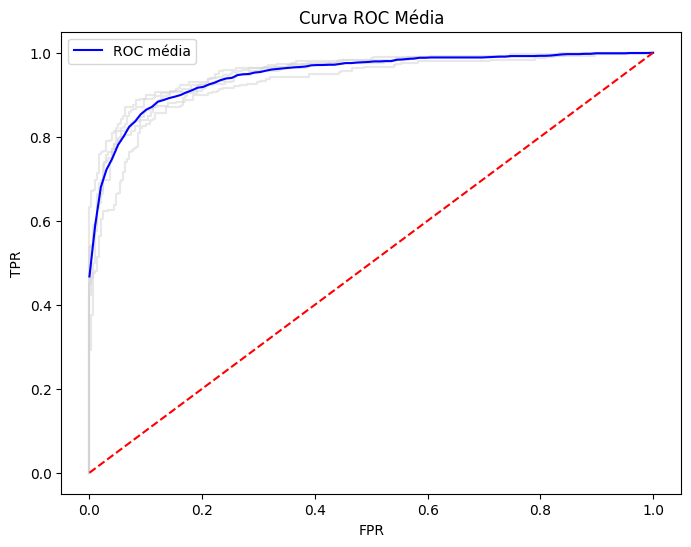

In [22]:

# === Configurações ===
model_name = "melll-uff/bertweetbr"
tokenizer = AutoTokenizer.from_pretrained(model_name)


num_labels = df["label"].nunique()
id2label = {i: f"Classe {i}" for i in range(num_labels)}
label2id = {v: k for k, v in id2label.items()}


# Função de tokenização
def tokenize_fn(examples):
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=128)

# === Cross Validation ===
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

metrics_results = []
roc_curves = []
start_total = time.time()

for fold, (train_idx, test_idx) in enumerate(skf.split(df["text"], df["label"]), start=1):
    print(f"=== Fold {fold} ===")

    train_df = df.iloc[train_idx]
    test_df = df.iloc[test_idx]

    # Converte para Dataset do HF
    from datasets import Dataset
    train_dataset = Dataset.from_pandas(train_df).map(tokenize_fn, batched=True)
    test_dataset = Dataset.from_pandas(test_df).map(tokenize_fn, batched=True)

    # Carrega modelo novo a cada fold
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, 
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id,
        use_safetensors=True,
        ignore_mismatched_sizes=True  # o modelo foi treinado com 12 classes, mas estou ignorando o 
                                        # erro de incompatibilidade de forma na camada final e recriar a Linear layer com num_labels=3. 
    )

    # Configuração de treinamento
    training_args = TrainingArguments(
        #output_dir=f"./results_fold_{fold}",
        #evaluation_strategy="no",
        save_strategy="no",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=3,
        #logging_dir=f"./logs_fold_{fold}",
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        tokenizer=tokenizer
    )

    start_fold = time.time()
    trainer.train()
    elapsed_fold = time.time() - start_fold

    # Predições
    preds = trainer.predict(test_dataset)
    y_true = np.array(test_df["label"])
    y_pred = np.argmax(preds.predictions, axis=1)
    y_prob = preds.predictions[:, 1]

    # Métricas
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)

    metrics_results.append({
        "fold": fold,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": roc_auc,
        "time_sec": elapsed_fold
    })

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_curves.append((fpr, tpr))

total_time = time.time() - start_total

# === Estatísticas ===
metrics_df = pd.DataFrame(metrics_results)
summary = {
    "accuracy_avg": metrics_df["accuracy"].mean(),
    "accuracy_std": metrics_df["accuracy"].std(),
    "precision_avg": metrics_df["precision"].mean(),
    "precision_std": metrics_df["precision"].std(),
    "recall_avg": metrics_df["recall"].mean(),
    "recall_std": metrics_df["recall"].std(),
    "f1_avg": metrics_df["f1"].mean(),
    "f1_std": metrics_df["f1"].std(),
    "roc_auc_avg": metrics_df["roc_auc"].mean(),
    "roc_auc_std": metrics_df["roc_auc"].std(),
    "total_time_sec": total_time
}

# Salvar CSV
metrics_df.to_csv("./resultados/resultados_folds_melll_uff_Compre_processamento.csv", index=False)
pd.DataFrame([summary]).to_csv("./resultados/resultados_resumo_melll_uff_Compre_processamento.csv", index=False)

# === Plot Curva ROC média ===
plt.figure(figsize=(8, 6))
for fpr, tpr in roc_curves:
    plt.plot(fpr, tpr, color="lightgray", alpha=0.5)

mean_fpr = np.linspace(0, 1, 100)
mean_tpr = np.zeros_like(mean_fpr)
for fpr, tpr in roc_curves:
    mean_tpr += np.interp(mean_fpr, fpr, tpr)
mean_tpr /= len(roc_curves)

plt.plot(mean_fpr, mean_tpr, color="blue", label="ROC média")
plt.plot([0, 1], [0, 1], linestyle="--", color="red")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Curva ROC Média")
plt.legend()
plt.savefig("./resultados/roc_media_melll_uff_Compre_processamento.png", dpi=300)
plt.show()


### FpOliveira/tupi-bert-base-portuguese-cased

=== Fold 1 ===


Map: 100%|██████████| 600/600 [00:00<00:00, 15334.64 examples/s]
C:\Users\Melissa Felipe\AppData\Local\Temp\ipykernel_10016\283951782.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss


=== Fold 2 ===


Map: 100%|██████████| 600/600 [00:00<00:00, 16531.45 examples/s]
C:\Users\Melissa Felipe\AppData\Local\Temp\ipykernel_10016\283951782.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


...

Map: 100%|██████████| 600/600 [00:00<00:00, 15669.19 examples/s]
C:\Users\Melissa Felipe\AppData\Local\Temp\ipykernel_10016\283951782.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss


=== Fold 5 ===


Map: 100%|██████████| 600/600 [00:00<00:00, 15128.33 examples/s]
C:\Users\Melissa Felipe\AppData\Local\Temp\ipykernel_10016\283951782.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss


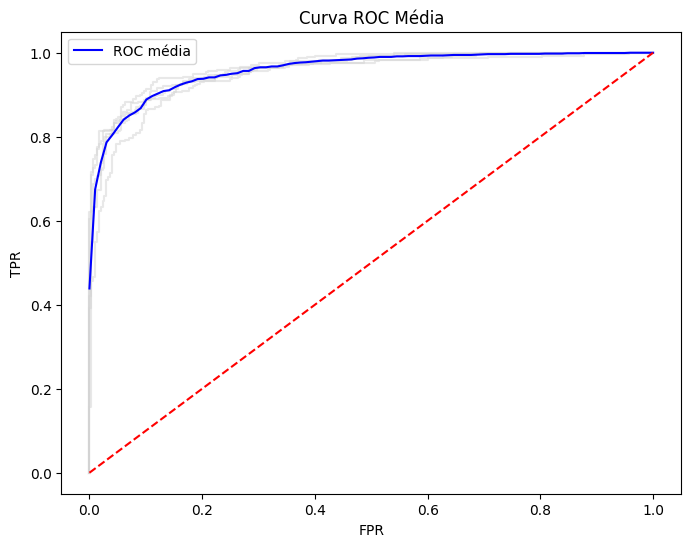

In [23]:

# === Configurações ===
model_name = "FpOliveira/tupi-bert-base-portuguese-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)


num_labels = df["label"].nunique()
id2label = {i: f"Classe {i}" for i in range(num_labels)}
label2id = {v: k for k, v in id2label.items()}


# Função de tokenização
def tokenize_fn(examples):
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=128)

# === Cross Validation ===
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

metrics_results = []
roc_curves = []
start_total = time.time()

for fold, (train_idx, test_idx) in enumerate(skf.split(df["text"], df["label"]), start=1):
    print(f"=== Fold {fold} ===")

    train_df = df.iloc[train_idx]
    test_df = df.iloc[test_idx]

    # Converte para Dataset do HF
    from datasets import Dataset
    train_dataset = Dataset.from_pandas(train_df).map(tokenize_fn, batched=True)
    test_dataset = Dataset.from_pandas(test_df).map(tokenize_fn, batched=True)

    # Carrega modelo novo a cada fold
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, 
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id,
        use_safetensors=True,
        ignore_mismatched_sizes=True  # o modelo foi treinado com 12 classes, mas estou ignorando o 
                                        # erro de incompatibilidade de forma na camada final e recriar a Linear layer com num_labels=3. 
    )

    # Configuração de treinamento
    training_args = TrainingArguments(
        #output_dir=f"./results_fold_{fold}",
        #evaluation_strategy="no",
        save_strategy="no",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=3,
        #logging_dir=f"./logs_fold_{fold}",
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        tokenizer=tokenizer
    )

    start_fold = time.time()
    trainer.train()
    elapsed_fold = time.time() - start_fold

    # Predições
    preds = trainer.predict(test_dataset)
    y_true = np.array(test_df["label"])
    y_pred = np.argmax(preds.predictions, axis=1)
    y_prob = preds.predictions[:, 1]

    # Métricas
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)

    metrics_results.append({
        "fold": fold,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": roc_auc,
        "time_sec": elapsed_fold
    })

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_curves.append((fpr, tpr))

total_time = time.time() - start_total

# === Estatísticas ===
metrics_df = pd.DataFrame(metrics_results)
summary = {
    "accuracy_avg": metrics_df["accuracy"].mean(),
    "accuracy_std": metrics_df["accuracy"].std(),
    "precision_avg": metrics_df["precision"].mean(),
    "precision_std": metrics_df["precision"].std(),
    "recall_avg": metrics_df["recall"].mean(),
    "recall_std": metrics_df["recall"].std(),
    "f1_avg": metrics_df["f1"].mean(),
    "f1_std": metrics_df["f1"].std(),
    "roc_auc_avg": metrics_df["roc_auc"].mean(),
    "roc_auc_std": metrics_df["roc_auc"].std(),
    "total_time_sec": total_time
}

# Salvar CSV
metrics_df.to_csv("./resultados/resultados_folds_FpOliveira_Compre_processamento.csv", index=False)
pd.DataFrame([summary]).to_csv("./resultados/resultados_resumo_FpOliveira_Compre_processamento.csv", index=False)

# === Plot Curva ROC média ===
plt.figure(figsize=(8, 6))
for fpr, tpr in roc_curves:
    plt.plot(fpr, tpr, color="lightgray", alpha=0.5)

mean_fpr = np.linspace(0, 1, 100)
mean_tpr = np.zeros_like(mean_fpr)
for fpr, tpr in roc_curves:
    mean_tpr += np.interp(mean_fpr, fpr, tpr)
mean_tpr /= len(roc_curves)

plt.plot(mean_fpr, mean_tpr, color="blue", label="ROC média")
plt.plot([0, 1], [0, 1], linestyle="--", color="red")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Curva ROC Média")
plt.legend()
plt.savefig("./resultados/roc_media_FpOliveira_Compre_processamento.png", dpi=300)
plt.show()


### ruanchaves/bert-base-portuguese-cased-hatebr

=== Fold 1 ===


Map: 100%|██████████| 600/600 [00:00<00:00, 17280.90 examples/s]
C:\Users\Melissa Felipe\AppData\Local\Temp\ipykernel_10016\2768694142.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss


=== Fold 2 ===


Map: 100%|██████████| 600/600 [00:00<00:00, 14613.96 examples/s]
C:\Users\Melissa Felipe\AppData\Local\Temp\ipykernel_10016\2768694142.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


...

Map: 100%|██████████| 600/600 [00:00<00:00, 19809.37 examples/s]
C:\Users\Melissa Felipe\AppData\Local\Temp\ipykernel_10016\2768694142.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss


=== Fold 5 ===


Map: 100%|██████████| 600/600 [00:00<00:00, 14018.94 examples/s]
C:\Users\Melissa Felipe\AppData\Local\Temp\ipykernel_10016\2768694142.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss


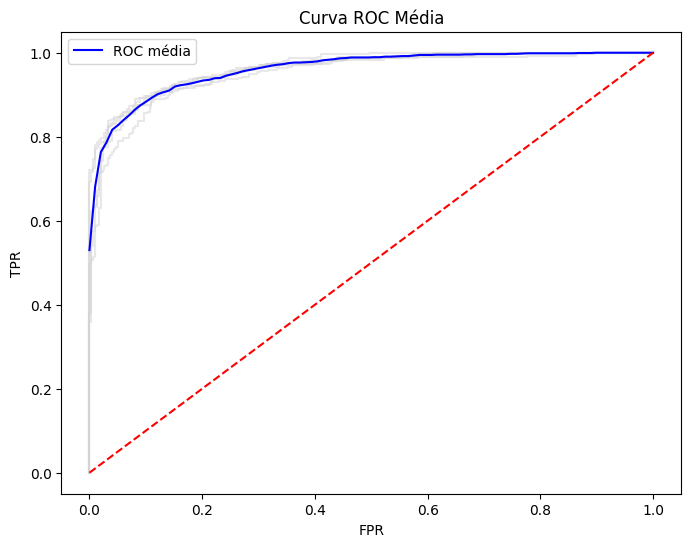

In [24]:

# === Configurações ===
model_name = "ruanchaves/bert-base-portuguese-cased-hatebr"
tokenizer = AutoTokenizer.from_pretrained(model_name)


num_labels = df["label"].nunique()
id2label = {i: f"Classe {i}" for i in range(num_labels)}
label2id = {v: k for k, v in id2label.items()}


# Função de tokenização
def tokenize_fn(examples):
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=128)

# === Cross Validation ===
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

metrics_results = []
roc_curves = []
start_total = time.time()

for fold, (train_idx, test_idx) in enumerate(skf.split(df["text"], df["label"]), start=1):
    print(f"=== Fold {fold} ===")

    train_df = df.iloc[train_idx]
    test_df = df.iloc[test_idx]

    # Converte para Dataset do HF
    from datasets import Dataset
    train_dataset = Dataset.from_pandas(train_df).map(tokenize_fn, batched=True)
    test_dataset = Dataset.from_pandas(test_df).map(tokenize_fn, batched=True)

    # Carrega modelo novo a cada fold
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, 
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id,
        use_safetensors=True,
        ignore_mismatched_sizes=True  # o modelo foi treinado com 12 classes, mas estou ignorando o 
                                        # erro de incompatibilidade de forma na camada final e recriar a Linear layer com num_labels=3. 
    )

    # Configuração de treinamento
    training_args = TrainingArguments(
        #output_dir=f"./results_fold_{fold}",
        #evaluation_strategy="no",
        save_strategy="no",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=3,
        #logging_dir=f"./logs_fold_{fold}",
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        tokenizer=tokenizer
    )

    start_fold = time.time()
    trainer.train()
    elapsed_fold = time.time() - start_fold

    # Predições
    preds = trainer.predict(test_dataset)
    y_true = np.array(test_df["label"])
    y_pred = np.argmax(preds.predictions, axis=1)
    y_prob = preds.predictions[:, 1]

    # Métricas
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)

    metrics_results.append({
        "fold": fold,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": roc_auc,
        "time_sec": elapsed_fold
    })

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_curves.append((fpr, tpr))

total_time = time.time() - start_total

# === Estatísticas ===
metrics_df = pd.DataFrame(metrics_results)
summary = {
    "accuracy_avg": metrics_df["accuracy"].mean(),
    "accuracy_std": metrics_df["accuracy"].std(),
    "precision_avg": metrics_df["precision"].mean(),
    "precision_std": metrics_df["precision"].std(),
    "recall_avg": metrics_df["recall"].mean(),
    "recall_std": metrics_df["recall"].std(),
    "f1_avg": metrics_df["f1"].mean(),
    "f1_std": metrics_df["f1"].std(),
    "roc_auc_avg": metrics_df["roc_auc"].mean(),
    "roc_auc_std": metrics_df["roc_auc"].std(),
    "total_time_sec": total_time
}

# Salvar CSV
metrics_df.to_csv("./resultados/resultados_folds_ruanchaves_Commpre_processamento.csv", index=False)
pd.DataFrame([summary]).to_csv("./resultados/resultados_resumo_ruanchaves_Compre_processamento.csv", index=False)

# === Plot Curva ROC média ===
plt.figure(figsize=(8, 6))
for fpr, tpr in roc_curves:
    plt.plot(fpr, tpr, color="lightgray", alpha=0.5)

mean_fpr = np.linspace(0, 1, 100)
mean_tpr = np.zeros_like(mean_fpr)
for fpr, tpr in roc_curves:
    mean_tpr += np.interp(mean_fpr, fpr, tpr)
mean_tpr /= len(roc_curves)

plt.plot(mean_fpr, mean_tpr, color="blue", label="ROC média")
plt.plot([0, 1], [0, 1], linestyle="--", color="red")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Curva ROC Média")
plt.legend()
plt.savefig("./resultados/roc_media_ruanchaves_Compre_processamento.png", dpi=300)
plt.show()
